In [1]:
"""
INTEGRATED FIGURE 1: Complete Analysis Pipeline
Fixed version with proper execution order
"""

# %%
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import warnings
from scipy.sparse import csr_matrix
from scipy import stats
from datetime import datetime
from tqdm import tqdm
from scipy import stats
from scipy.sparse import issparse
import sys 

warnings.filterwarnings("ignore")

# Import ATSE coordination functions
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation') 

# Plotting configuration
sns.set_theme(context="notebook", style="white")
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.grid': False,
})

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

gtf_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/2025_mouse_longread/2025_mouse_collapse_GRCm38/all_samples_sp_collapse_all_chr_full.gtf"
db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/genomes/lr_GRCm38.db"

# Load the database
db_mouse = gffutils.FeatureDB(db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [2]:
# Setup
today = datetime.now().strftime("%Y%m%d")
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"

# =========================================================================
# PART 1: Load and Preprocess Data
# =========================================================================

print("\n" + "="*60)
print("PART 1: DATA LOADING AND PREPROCESSING")
print("="*60)

SPLICE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/preprocessed_data_20251019.h5ad"
ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-10-01_21-36-40.txt.gz"
full_atse_map = pd.read_csv(ATSE_FILE_PATH, sep="\t")

print("Loading data...")
splice_adata = ad.read_h5ad(SPLICE_INPUT)
print(f"Loaded {splice_adata.n_obs:,} cells and {splice_adata.n_vars:,} junctions")

output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE1/pdfs"
# make output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# load all ATSEs for coordination analysis 
all_juncs = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/junction_df_all_20251020.csv"
all_atses = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/FIGURES/FIGURE1/figure1_20251019/atse_df_all_20251020.csv"
all_juncs_df = pd.read_csv(all_juncs)
all_atses_df = pd.read_csv(all_atses)
all_juncs_df.head()
all_atses_df.head()


PART 1: DATA LOADING AND PREPROCESSING
Loading data...
Loaded 85,692 cells and 52,290 junctions


,cell_type,event_id,n_junctions,mean_delta_mean,median_delta_median,mean_abs_delta,std_delta,sign_concordance,mean_delta_pb,median_delta_pb,opposite_sign_pair
0,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019966.18_atse_1,2,-1.387779e-17,0.000000,0.004092,0.005787,0.500000,1.040834e-17,1.040834e-17,1.0
1,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019966.18_atse_2,3,2.775558e-17,-0.006706,0.022149,0.029925,0.666667,9.251859e-18,1.517588e-02,NaN
2,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000036676.14_atse_2,2,-2.775558e-17,0.000000,0.142857,0.202031,0.500000,-1.387779e-17,-1.387779e-17,1.0
3,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000036676.14_atse_1,4,0.000000e+00,0.000000,0.107143,0.163684,0.750000,-2.775558e-17,7.836134e-02,NaN
4,Brain_Non-Myeloid_Endothelial cell,ENSMUSG00000019971.10_atse_1,3,9.251859e-18,0.000000,0.047619,0.071429,0.500000,-1.850372e-17,0.000000e+00,NaN


Unique transcripts: {'s09ce3b26201635ab:e5e4b6b24e6a5211e', 's8d433f13a060ca29:e804440dc19f45865', 'sbf3bb59a0d23ea27:e88359babfac65223', 'sb82d90465fa0c3d9:e45e0b1cc5afcc2c2', 'sbf3bb59a0d23ea27:ee2fb2adef3804f0b', 's9572fc2e753b2be3:e02f3798bfd358433', 'ENSMUST00000015358.7', 's52a723ecf8923526:e7f884f871c1e371e', 'sab5e637702806b8e:e439160cfd11e65cb', 'sa16d0c5f9419d53a:e1c211392e3204fce', 's2456d0b7b087af3c:e439160cfd11e65cb', 's38b43faf27fe6312:efe0c8a6c64d19426', 'sd8689a403eba5ece:e43ed8ea00149db54', 'sd715fd4934356458:e5e4b6b24e6a5211e'}


Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/ATSE_plotter/010112_mouse_nan_ENSMUSG00000015214.14_atse_1.pdf!


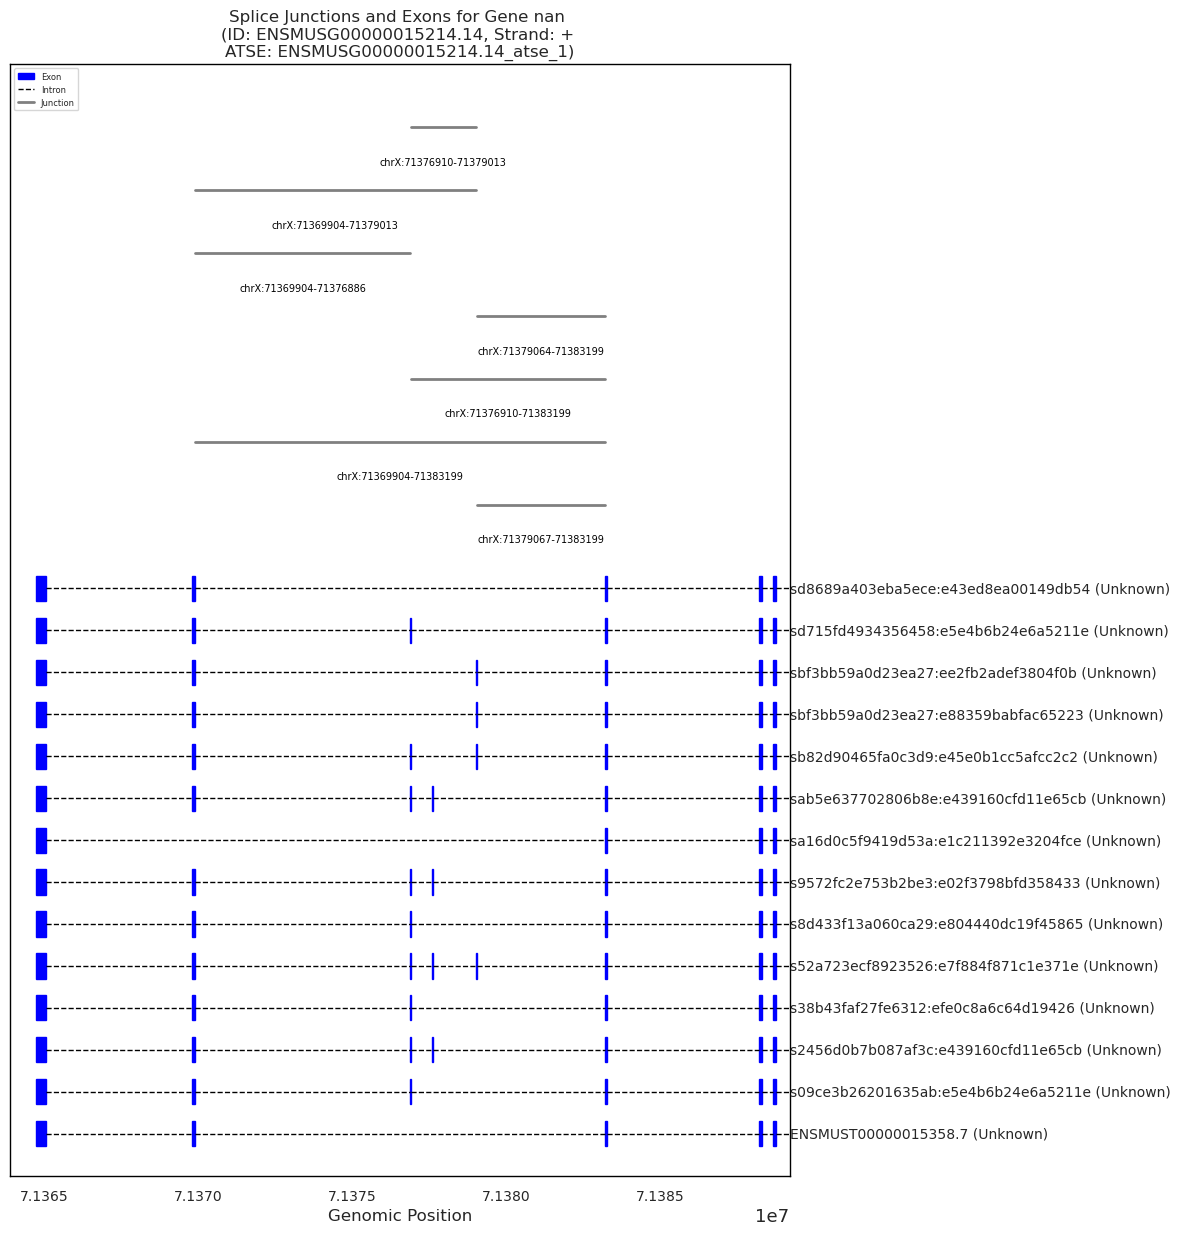

ATSE visualization saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/ATSE_plotter/010112_mouse_nan_ENSMUSG00000015214.14_atse_1.pdf


{'junctions':                            event_id                gene_id  gene_name  \
 72891  ENSMUSG00000015214.14_atse_1  ENSMUSG00000015214.14        NaN   
 72892  ENSMUSG00000015214.14_atse_1  ENSMUSG00000015214.14        NaN   
 72893  ENSMUSG00000015214.14_atse_1  ENSMUSG00000015214.14        NaN   
 72894  ENSMUSG00000015214.14_atse_1  ENSMUSG00000015214.14        NaN   
 72895  ENSMUSG00000015214.14_atse_1  ENSMUSG00000015214.14        NaN   
 72896  ENSMUSG00000015214.14_atse_1  ENSMUSG00000015214.14        NaN   
 72897  ENSMUSG00000015214.14_atse_1  ENSMUSG00000015214.14        NaN   
 
        gene_types  num_junctions event_type chromosome strand  atse_start  \
 72891         NaN              7    complex       chrX      +    71369904   
 72892         NaN              7    complex       chrX      +    71369904   
 72893         NaN              7    complex       chrX      +    71369904   
 72894         NaN              7    complex       chrX      +    71369904   
 72

In [4]:
mouse_event = "ENSMUSG00000015214.14_atse_1"
visualize_atse_event(mouse_event, full_atse_map, db_mouse,
                 species="mouse", base_width=12, 
                       trans_height=0.8, output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/ATSE_plotter",
                  padding=5000, show_junc_lines=False, filter_ensembl_transcripts=False)